# 05 — BOCPD Synthetic Changepoint Evaluation

Validates that BOCPD **detects known changepoints** when they exist. Real EEG data appears stationary; this notebook injects synthetic mean/variance shifts and evaluates detection accuracy and latency.

**Goal 11** from results.md. Reference: Adams & MacKay (2007).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.stats import norm

def logsumexp(x):
    m = np.max(x)
    return m + np.log(np.sum(np.exp(x - m)))

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else (Path.cwd() / ".." / "..").resolve()
ARTIFACTS_FIG = ROOT / "artifacts" / "figures" / "bocpd"
ARTIFACTS_FIG.mkdir(parents=True, exist_ok=True)
HAZARD = 0.02

In [2]:
def bocpd_gaussian(x, hazard=0.02, mean0=None, var0=1.0, varx=None):
    T = len(x)
    if mean0 is None:
        mean0 = np.mean(x)
    if varx is None:
        varx = np.var(x) + 1e-6
    prec0 = 1.0 / var0
    precx = 1.0 / varx
    log_H = np.log(hazard)
    log_1mH = np.log(1 - hazard)
    R = np.zeros((T + 1, T + 1))
    cp_prob = np.zeros(T)
    prec_params = np.array([prec0])
    mean_params = np.array([mean0])
    log_message = np.array([0.0])
    for t in range(T):
        xt = x[t]
        post_prec = prec_params[: t + 1]
        post_var = 1.0 / post_prec + varx
        post_std = np.sqrt(post_var)
        log_preds = norm.logpdf(xt, mean_params[: t + 1], post_std)
        log_growth = log_preds + log_message + log_1mH
        # CP: predict from prior (log_preds[0]); sum over prev run-lengths (Adams & MacKay)
        log_cp = log_preds[0] + log_H + logsumexp(log_message)
        new_log_joint = np.append(log_cp, log_growth)
        new_log_joint -= logsumexp(new_log_joint)
        R[t, : t + 2] = np.exp(new_log_joint)
        cp_prob[t] = np.exp(new_log_joint[0])
        new_prec = prec_params + precx
        prec_params = np.append([prec0], new_prec)
        new_mean = (mean_params * prec_params[:-1] + xt * precx) / new_prec
        mean_params = np.append([mean0], new_mean)
        log_message = new_log_joint
    return R[:T], cp_prob


def generate_synthetic(seed, n=100, cp_true=50, cp_type="mean", effect_size=1.5, noise_std=0.5):
    """Generate sequence with known changepoint. cp_true = index (0-based)."""
    rng = np.random.default_rng(seed)
    if cp_type == "mean":
        x = np.concatenate([
            rng.normal(0, noise_std, cp_true),
            rng.normal(effect_size, noise_std, n - cp_true)
        ])
    elif cp_type == "variance":
        x = np.concatenate([
            rng.normal(0, noise_std, cp_true),
            rng.normal(0, noise_std * effect_size, n - cp_true)
        ])
    else:
        raise ValueError(cp_type)
    return x, cp_true


def generate_no_cp(seed, n=100, mean=0, noise_std=0.5):
    """Stationary sequence (no changepoint)."""
    rng = np.random.default_rng(seed)
    return rng.normal(mean, noise_std, n), None

## Example: mean shift at t=50

In [3]:
np.random.seed(42)
NOISE_STD = 0.5
x, cp_true = generate_synthetic(42, n=100, cp_true=50, cp_type="mean", effect_size=1.5, noise_std=NOISE_STD)
# Use known observation variance and mean0=0 (first-segment prior) for synthetic
R, cp_prob = bocpd_gaussian(x, hazard=HAZARD, mean0=0, varx=NOISE_STD**2)
idx_detected = np.argmax(cp_prob)
print(f"True CP at t={cp_true}; detected peak at t={idx_detected}, prob={cp_prob[idx_detected]:.3f}")
print(f"Max cp_prob = {cp_prob.max():.3f}")

True CP at t=50; detected peak at t=50, prob=0.260
Max cp_prob = 0.260


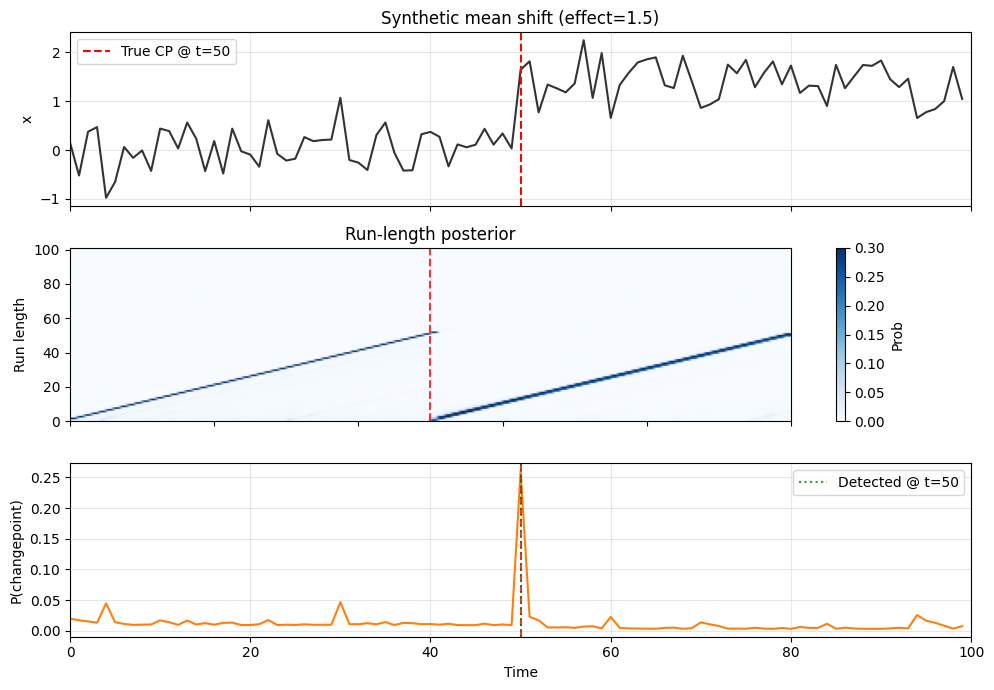

Saved bocpd__synthetic_mean_shift__2026-02-27.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
t_axis = np.arange(len(x))
axes[0].plot(t_axis, x, "k-", alpha=0.8)
axes[0].axvline(cp_true, color="red", ls="--", label=f"True CP @ t={cp_true}")
axes[0].set_ylabel("x")
axes[0].set_title("Synthetic mean shift (effect=1.5)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
im = axes[1].imshow(R.T[:, : len(x)], aspect="auto", origin="lower", cmap="Blues",
                    extent=[0, len(x), 0, R.shape[1]], vmin=0, vmax=0.3)
axes[1].axvline(cp_true, color="red", ls="--", alpha=0.8)
axes[1].set_ylabel("Run length")
axes[1].set_title("Run-length posterior")
plt.colorbar(im, ax=axes[1], label="Prob")
axes[2].plot(t_axis, cp_prob, "C1-", lw=1.5)
axes[2].axvline(cp_true, color="red", ls="--", alpha=0.8)
axes[2].axvline(idx_detected, color="green", ls=":", alpha=0.8, label=f"Detected @ t={idx_detected}")
axes[2].set_ylabel("P(changepoint)")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
out_path = ARTIFACTS_FIG / "bocpd__synthetic_mean_shift__2026-02-27.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {out_path.name}")

## Systematic evaluation: detection rate and latency

In [5]:
def evaluate_detection(n_trials=100, n=100, cp_true=50, cp_type="mean", effect_size=1.5, noise_std=0.5, hazard=0.02, tol=10):
    """Run BOCPD on n_trials synthetic sequences. Uses fixed varx=noise_std^2 (known in synthetic)."""
    detected = []
    latencies = []
    max_probs = []
    varx = noise_std**2
    mean0 = 0  # first-segment mean (synthetic)
    for seed in range(n_trials):
        x, _ = generate_synthetic(seed, n=n, cp_true=cp_true, cp_type=cp_type, effect_size=effect_size, noise_std=noise_std)
        _, cp_prob = bocpd_gaussian(x, hazard=hazard, mean0=mean0, varx=varx)
        idx = np.argmax(cp_prob)
        max_probs.append(cp_prob.max())
        latencies.append(idx - cp_true)
        detected.append(abs(idx - cp_true) <= tol)
    return {
        "detection_rate": np.mean(detected),
        "mean_latency": np.mean(latencies),
        "std_latency": np.std(latencies),
        "mean_max_cp_prob": np.mean(max_probs),
    }


def evaluate_no_cp(n_trials=100, n=100, noise_std=0.5, hazard=0.02, threshold=0.5):
    """False positive rate: how often max_cp_prob > threshold on stationary data."""
    max_probs = []
    varx = noise_std**2
    mean0 = 0
    for seed in range(n_trials):
        x, _ = generate_no_cp(seed, n=n, noise_std=noise_std)
        _, cp_prob = bocpd_gaussian(x, hazard=hazard, mean0=mean0, varx=varx)
        max_probs.append(cp_prob.max())
    return {
        "fp_rate": np.mean(np.array(max_probs) > threshold),
        "mean_max_cp_prob": np.mean(max_probs),
    }

In [6]:
rows = []
for effect in [0.5, 1.0, 1.5, 2.0]:
    r = evaluate_detection(n_trials=100, cp_type="mean", effect_size=effect, tol=15)
    rows.append({"effect_size": effect, "cp_type": "mean", **r})
for effect in [1.5, 2.0, 2.5, 3.0]:
    r = evaluate_detection(n_trials=100, cp_type="variance", effect_size=effect, tol=15)
    rows.append({"effect_size": effect, "cp_type": "variance", **r})

no_cp = evaluate_no_cp(n_trials=200)
print("Detection (mean shift):")
print(pd.DataFrame([r for r in rows if r["cp_type"] == "mean"]).to_string(index=False))
print("\nDetection (variance shift):")
print(pd.DataFrame([r for r in rows if r["cp_type"] == "variance"]).to_string(index=False))
print(f"\nNo-CP (stationary): mean_max_cp_prob={no_cp['mean_max_cp_prob']:.3f}, fp_rate(>0.5)={no_cp['fp_rate']:.2%}")

Detection (mean shift):
 effect_size cp_type  detection_rate  mean_latency  std_latency  mean_max_cp_prob
         0.5    mean            0.44          0.75    26.856051          0.161937
         1.0    mean            0.60         -1.31    23.250675          0.193391
         1.5    mean            0.72         -1.44    19.116652          0.265943
         2.0    mean            0.91         -0.12    10.564355          0.416943

Detection (variance shift):
 effect_size  cp_type  detection_rate  mean_latency  std_latency  mean_max_cp_prob
         1.5 variance            0.33         22.10    18.258970          0.368740
         2.0 variance            0.24         26.25    15.747619          0.569447
         2.5 variance            0.27         27.09    13.468552          0.689743
         3.0 variance            0.27         26.75    14.018113          0.771812

No-CP (stationary): mean_max_cp_prob=0.142, fp_rate(>0.5)=1.00%


## Save summary table

In [7]:
eval_df = pd.DataFrame(rows)
table_path = ROOT / "artifacts" / "tables" / "bocpd__synthetic_evaluation__2026-02-27.csv"
table_path.parent.mkdir(parents=True, exist_ok=True)
eval_df.to_csv(table_path, index=False)
print(f"Saved {table_path}")

no_cp_row = pd.DataFrame([{
    "effect_size": np.nan,
    "cp_type": "none",
    "detection_rate": np.nan,
    "mean_latency": np.nan,
    "std_latency": np.nan,
    "mean_max_cp_prob": no_cp["mean_max_cp_prob"],
}])
no_cp_path = ROOT / "artifacts" / "tables" / "bocpd__synthetic_no_cp__2026-02-27.csv"
no_cp_row.to_csv(no_cp_path, index=False)
print(f"Saved {no_cp_path}")

Saved C:\Users\sardo\OneDrive\Desktop\Classes\Bayesian-Detection-for-EEG\artifacts\tables\bocpd__synthetic_evaluation__2026-02-27.csv
Saved C:\Users\sardo\OneDrive\Desktop\Classes\Bayesian-Detection-for-EEG\artifacts\tables\bocpd__synthetic_no_cp__2026-02-27.csv
